# BDF Solver for the Robertson Problem

This notebook mirrors `Parallel/BDF.py` and demonstrates solving the stiff Robertson ODE system
using SciPy's implicit `BDF` method, then plotting the three species over time.


## Imports


In [1]:
from typing import Callable, Sequence, Optional, Tuple, Any, List, Dict
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from concurrent.futures import ProcessPoolExecutor, as_completed


## Helper Function

Top-level wrapper used by `ProcessPoolExecutor` so each IVP instance can be solved independently.


In [2]:
def _solve_single(instance):
    # Top-level helper for multiprocessing: instance is a tuple
    ode_func, t_span, y0, args, t_eval, atol, rtol, method = instance
    return solve_ivp(
        fun=ode_func,
        t_span=t_span,
        y0=y0,
        args=args or (),
        t_eval=t_eval,
        atol=atol,
        rtol=rtol,
        method=method,
    )


## Batched BDF Solver

This function solves a batch of initial-value problems using `solve_ivp(..., method='BDF')` and
returns both the solver results and timing estimates.


In [3]:
def solve_batched_bdf(
    ode_func: Callable[[float, np.ndarray, Any], np.ndarray],
    t_span: Tuple[float, float],
    y0_batch: Sequence[np.ndarray],
    args_batch: Optional[Sequence[Tuple]] = None,
    t_eval: Optional[np.ndarray] = None,
    atol: float = 1e-6,
    rtol: float = 1e-3,
    method: str = "BDF",
    parallel: bool = False,
    n_workers: Optional[int] = None,
    warmup: int = 0,
    repeats: int = 1,
) -> Dict[str, Any]:
    """
    Solve a batch of IVPs using scipy.integrate.solve_ivp with method='BDF'.

    Returns a dict containing:
      - results: list of solve_ivp result objects
      - timings: average total/per-instance timings across repeats
    """
    batch_size = len(y0_batch)
    if args_batch is None:
        args_batch = [() for _ in range(batch_size)]
    assert len(args_batch) == batch_size, "args_batch length must match y0_batch"

    # Prepare instances for serial or parallel execution
    instances = [
        (ode_func, t_span, np.asarray(y0_batch[i]), args_batch[i], t_eval, atol, rtol, method)
        for i in range(batch_size)
    ]

    def run_once(executor=None):
        results = [None] * batch_size
        per_instance_times = [0.0] * batch_size

        if executor is None:
            # Serial execution
            for i, inst in enumerate(instances):
                t0 = time.perf_counter()
                res = _solve_single(inst)
                t1 = time.perf_counter()
                results[i] = res
                per_instance_times[i] = t1 - t0
        else:
            # Parallel execution using ProcessPoolExecutor
            futures = {executor.submit(_solve_single, inst): idx for idx, inst in enumerate(instances)}
            for fut in as_completed(futures):
                idx = futures[fut]
                t_start = time.perf_counter()
                res = fut.result()
                t_end = time.perf_counter()
                results[idx] = res
                # Approximate per-instance collection time (not exact wall solve time)
                per_instance_times[idx] = t_end - t_start

        total = sum(per_instance_times)
        return results, per_instance_times, total

    # Warmup runs (not timed)
    for _ in range(warmup):
        if parallel:
            with ProcessPoolExecutor(max_workers=n_workers) as execp:
                run_once(execp)
        else:
            run_once(None)

    # Timed repeats
    totals = []
    per_instance_lists = []
    last_results = None

    for _ in range(repeats):
        if parallel:
            with ProcessPoolExecutor(max_workers=n_workers) as execp:
                results, per_inst, total = run_once(execp)
        else:
            results, per_inst, total = run_once(None)

        totals.append(total)
        per_instance_lists.append(per_inst)
        last_results = results

    avg_total = float(np.mean(totals))
    avg_per_instance = (
        float(np.mean(per_instance_lists, axis=0).sum() / batch_size)
        if batch_size > 0
        else 0.0
    )

    return {
        "results": last_results,
        "timings": {
            "per_instance": avg_per_instance,
            "total": avg_total,
            "per_instance_list": list(np.mean(per_instance_lists, axis=0)),
        },
    }


## Robertson Problem (Stiff ODE)



In [4]:
def robertson(t, y):
    y1, y2, y3 = y
    dy1 = -0.04 * y1 + 1e4 * y2 * y3
    dy2 = 0.04 * y1 - 1e4 * y2 * y3 - 3e7 * y2 * y2
    dy3 = 3e7 * y2 * y2
    return np.array([dy1, dy2, dy3])


## Solve the Robertson Problem

We use the standard initial condition `y(0) = [1, 0, 0]`, a wide time window, and log-spaced
sampling points to capture the fast and slow timescales in a single run.


In [5]:
# Robertson problem standard initial condition
batch = [np.array([1.0, 0.0, 0.0])]

# Wide time span + log-spaced sampling for stiff dynamics
t_span = (0.0, 1e5)
t_eval = np.concatenate(([0.0], np.logspace(-8, 5, 400)))

out = solve_batched_bdf(
    ode_func=robertson,
    t_span=t_span,
    y0_batch=batch,
    args_batch=None,
    t_eval=t_eval,
    atol=1e-10,
    rtol=1e-8,
    parallel=False,
    warmup=0,
    repeats=1,
)

print("Avg total batch time (s):", out["timings"]["total"])
print("Avg per-instance time (s):", out["timings"]["per_instance"])
print("Success flags:", [res.success for res in out["results"]])


Avg total batch time (s): 0.035365667019505054
Avg per-instance time (s): 0.035365667019505054
Success flags: [True]


## Plot the Solution

A semilogarithmic x-axis is used to make the transient behavior visible across many decades of time.


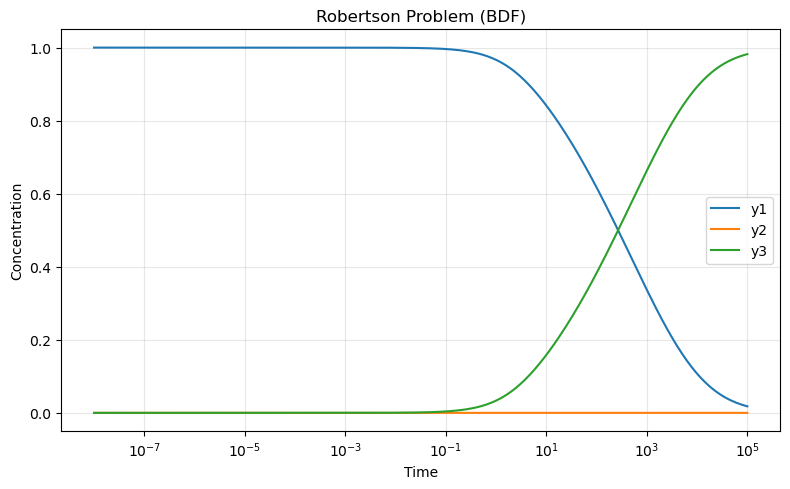

In [6]:
res = out["results"][0]
if not res.success:
    raise RuntimeError(f"Robertson solve failed: {res.message}")

plt.figure(figsize=(8, 5))
plt.semilogx(res.t[1:], res.y[0, 1:], label="y1")
plt.semilogx(res.t[1:], res.y[1, 1:], label="y2")
plt.semilogx(res.t[1:], res.y[2, 1:], label="y3")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Robertson Problem (BDF)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
